In [1]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

# ================= CONFIG =================
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
pd.set_option('display.max_rows', 200)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

SAMPLE_RATE = 360

DATA_DIR = Path("/kaggle/input/datasets/mondejar/mitbih-database")

CSV_FILES = sorted(DATA_DIR.glob('*.csv'))
ANNOTATION_FILES = sorted(DATA_DIR.glob('*annotations.txt'))

print(f'Data dir: {DATA_DIR}')
print(f'CSV files: {len(CSV_FILES)}')
print(f'Annotation files: {len(ANNOTATION_FILES)}')

# ================= LOAD CSV =================
def load_ecg_csv(path: Path) -> pd.DataFrame:
    # 🔥 FIX: đọc không header
    df = pd.read_csv(path, header=None)

    # dataset thường có 3 cột: sample, MLII, Vx
    if df.shape[1] == 3:
        df.columns = ['sample', 'MLII', 'Vx']
    elif df.shape[1] == 2:
        df.columns = ['sample', 'MLII']
    else:
        raise ValueError(f'Unexpected number of columns in {path.name}: {df.shape[1]}')

    # convert numeric
    df['sample'] = pd.to_numeric(df['sample'], errors='coerce')
    for col in df.columns:
        if col != 'sample':
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.dropna(subset=['sample']).reset_index(drop=True)
    df['sample'] = df['sample'].astype(int)

    return df

# ================= LOAD ANNOTATION =================
ANNOTATION_PATTERN = re.compile(
    r'^\s*(?P<time>\S+)\s+(?P<sample>\d+)\s+(?P<type>\S+)\s+(?P<sub>\d+)\s+(?P<chan>\d+)\s+(?P<num>\d+)\s*(?P<aux>.*)$'
)

def load_annotations_txt(path: Path) -> pd.DataFrame:
    rows = []
    with path.open('r', encoding='utf-8', errors='ignore') as handle:
        for line_number, line in enumerate(handle, start=1):
            if line_number == 1 or not line.strip():
                continue
            match = ANNOTATION_PATTERN.match(line.rstrip())
            if match is None:
                continue
            row = match.groupdict()
            row['sample'] = int(row['sample'])
            row['sub'] = int(row['sub'])
            row['chan'] = int(row['chan'])
            row['num'] = int(row['num'])
            rows.append(row)

    ann = pd.DataFrame(rows)
    if not ann.empty:
        ann['time_seconds'] = ann['time'].map(lambda value: pd.to_timedelta(value).total_seconds())
    return ann

# ================= HELPERS =================
def record_id_from_path(path: Path) -> str:
    return path.stem

def infer_channel_columns(df: pd.DataFrame) -> list[str]:
    return [col for col in df.columns if col != 'sample']

def is_beatsymbol(symbol: str) -> bool:
    return symbol not in {'+', '~', '|', 'x', 'Q', 'S'}

# ================= LOAD BUNDLE =================
def load_record_bundle(csv_path: Path) -> dict:
    record_id = record_id_from_path(csv_path)

    # 🔥 FIX: thêm dấu _
    annotation_path = DATA_DIR / f'{record_id}_annotations.txt'

    signals = load_ecg_csv(csv_path)
    annotations = load_annotations_txt(annotation_path) if annotation_path.exists() else pd.DataFrame()

    channel_columns = infer_channel_columns(signals)

    return {
        'record_id': record_id,
        'signals': signals,
        'annotations': annotations,
        'channel_columns': channel_columns,
        'csv_path': csv_path,
        'annotation_path': annotation_path if annotation_path.exists() else None,
    }

def detect_abnormal_labels(series: pd.Series) -> pd.Series:
    return ~series.isin(['N'])

# ================= RUN =================
records = [load_record_bundle(path) for path in CSV_FILES]

print(f'Loaded records: {len(records)}')

# test 1 record
print(records[0]['signals'].head())
print(records[0]['annotations'].head())

Data dir: /kaggle/input/datasets/mondejar/mitbih-database
CSV files: 48
Annotation files: 48


/tmp/ipykernel_57/2312254333.py:40: DtypeWarning: Columns (0,1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, header=None)
/tmp/ipykernel_57/2312254333.py:40: DtypeWarning: Columns (0,1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, header=None)
/tmp/ipykernel_57/2312254333.py:40: DtypeWarning: Columns (0,1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, header=None)
/tmp/ipykernel_57/2312254333.py:40: DtypeWarning: Columns (0,1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, header=None)
/tmp/ipykernel_57/2312254333.py:40: DtypeWarning: Columns (0,1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, header=None)
/tmp/ipykernel_57/2312254333.py:40: DtypeWarning: Columns (0,1,2) have mixed types. Specify dtype option on im

Loaded records: 48
   sample   MLII      Vx
0       0  995.0  1011.0
1       1  995.0  1011.0
2       2  995.0  1011.0
3       3  995.0  1011.0
4       4  995.0  1011.0
Empty DataFrame
Columns: []
Index: []


In [2]:
record_summary_rows = []
for record in records:
    signals = record['signals']
    annotations = record['annotations']
    duration_seconds = (signals['sample'].iloc[-1] - signals['sample'].iloc[0]) / SAMPLE_RATE if len(signals) > 1 else np.nan
    annotation_count = len(annotations)
    beat_annotations = annotations[annotations['type'].map(is_beatsymbol)] if not annotations.empty else annotations
    beat_count = len(beat_annotations)
    row = {
        'record_id': record['record_id'],
        'rows': len(signals),
        'duration_min_est': duration_seconds / 60 if pd.notna(duration_seconds) else np.nan,
        'channels': ', '.join(record['channel_columns']),
        'annotation_count': annotation_count,
        'beat_count': beat_count,
        'signal_min': signals[record['channel_columns']].min().min(),
        'signal_max': signals[record['channel_columns']].max().max(),
    }
    record_summary_rows.append(row)

record_summary = pd.DataFrame(record_summary_rows).sort_values('record_id').reset_index(drop=True)
display(record_summary.head(10))

print('Tổng số record:', len(record_summary))
print('Tổng số annotation:', int(record_summary['annotation_count'].sum()))
print('Tổng số beat annotation:', int(record_summary['beat_count'].sum()))
print('Thời lượng trung bình (phút, ước tính):', round(record_summary['duration_min_est'].mean(), 2))

,record_id,rows,duration_min_est,channels,annotation_count,beat_count,signal_min,signal_max
0,100,650000,30.092546,"MLII, Vx",0,0,481.0,1311.0
1,101,650000,30.092546,"MLII, Vx",0,0,389.0,1508.0
2,102,650000,30.092546,"MLII, Vx",0,0,350.0,1531.0
3,103,650000,30.092546,"MLII, Vx",0,0,0.0,2047.0
4,104,650000,30.092546,"MLII, Vx",0,0,637.0,1419.0
5,105,650000,30.092546,"MLII, Vx",0,0,281.0,1624.0
6,106,650000,30.092546,"MLII, Vx",0,0,491.0,1538.0
7,107,650000,30.092546,"MLII, Vx",0,0,349.0,1717.0
8,108,650000,30.092546,"MLII, Vx",0,0,126.0,1654.0
9,109,650000,30.092546,"MLII, Vx",0,0,385.0,1650.0


Tổng số record: 48
Tổng số annotation: 0
Tổng số beat annotation: 0
Thời lượng trung bình (phút, ước tính): 30.09


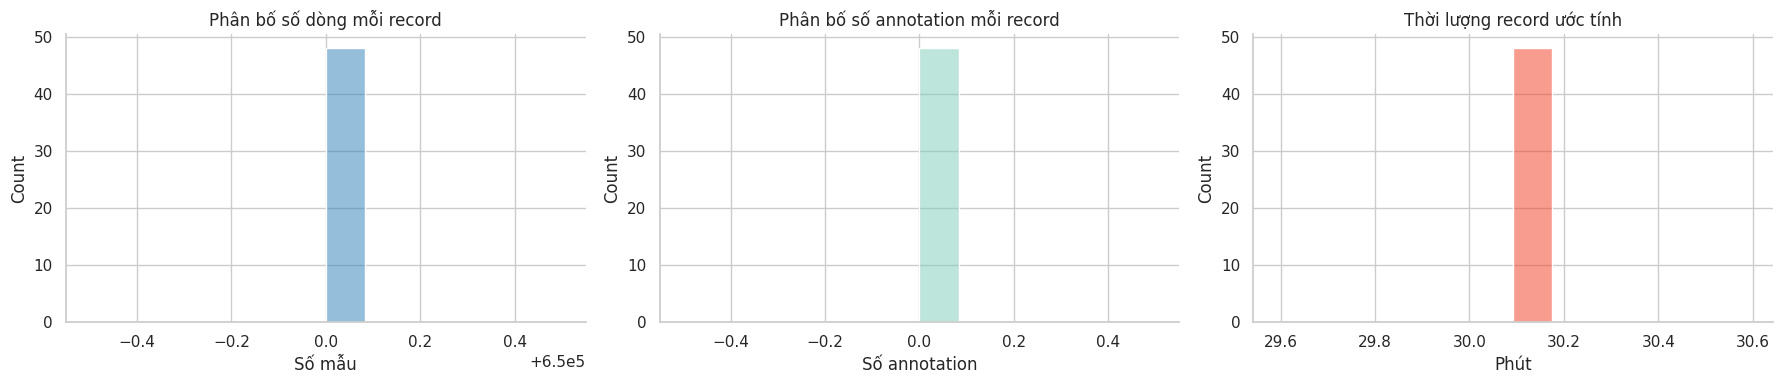

/tmp/ipykernel_57/2739788787.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_counts, x='channels', y='count', ax=ax, palette='viridis')


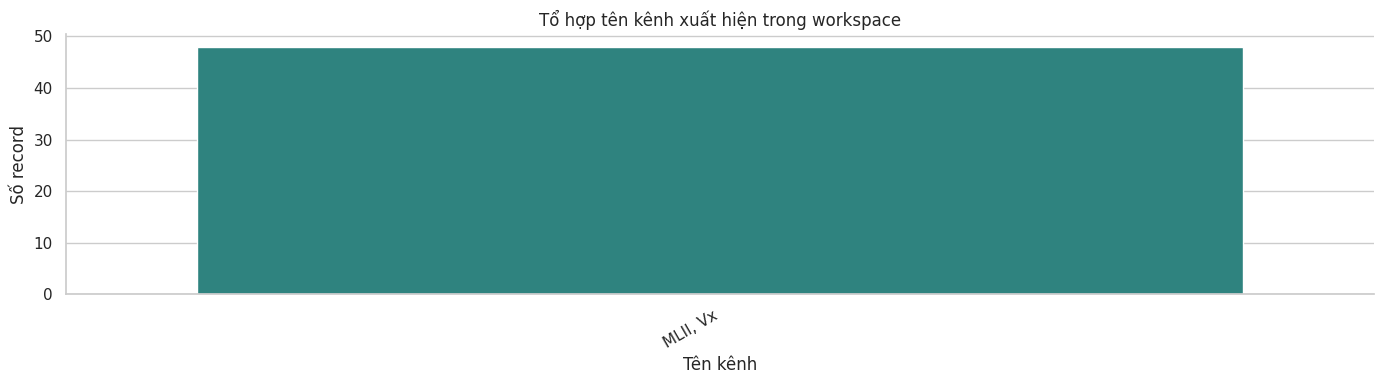

In [3]:
# Overview visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(record_summary['rows'], bins=12, kde=True, ax=axes[0], color='#2c7fb8')
axes[0].set_title('Phân bố số dòng mỗi record')
axes[0].set_xlabel('Số mẫu')

sns.histplot(record_summary['annotation_count'], bins=12, kde=True, ax=axes[1], color='#7fcdbb')
axes[1].set_title('Phân bố số annotation mỗi record')
axes[1].set_xlabel('Số annotation')

sns.histplot(record_summary['duration_min_est'], bins=12, kde=True, ax=axes[2], color='#f03b20')
axes[2].set_title('Thời lượng record ước tính')
axes[2].set_xlabel('Phút')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
channel_counts = record_summary['channels'].value_counts().reset_index()
channel_counts.columns = ['channels', 'count']
sns.barplot(data=channel_counts, x='channels', y='count', ax=ax, palette='viridis')
ax.set_title('Tổ hợp tên kênh xuất hiện trong workspace')
ax.set_xlabel('Tên kênh')
ax.set_ylabel('Số record')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [4]:
all_annotations = []
for record in records:
    annotations = record['annotations'].copy()
    if annotations.empty:
        continue
    annotations['record_id'] = record['record_id']
    all_annotations.append(annotations)

annotations_df = pd.concat(all_annotations, ignore_index=True) if all_annotations else pd.DataFrame()
beat_annotations_df = annotations_df[annotations_df['type'].map(is_beatsymbol)].copy() if not annotations_df.empty else pd.DataFrame()

display(annotations_df.head())

label_counts = annotations_df['type'].value_counts().reset_index() if not annotations_df.empty else pd.DataFrame(columns=['index', 'type'])
if not annotations_df.empty:
    label_counts.columns = ['label', 'count']
    label_counts['is_beat'] = label_counts['label'].map(is_beatsymbol)
    display(label_counts.head(20))

if not annotations_df.empty:
    fig, ax = plt.subplots(figsize=(14, 5))
    top_labels = label_counts.sort_values('count', ascending=False).head(15)
    sns.barplot(data=top_labels, x='label', y='count', ax=ax, palette='magma')
    ax.set_title('15 nhãn annotation xuất hiện nhiều nhất')
    ax.set_xlabel('Nhãn')
    ax.set_ylabel('Số lần xuất hiện')
    plt.tight_layout()
    plt.show()

    beat_label_counts = label_counts[label_counts['is_beat']].sort_values('count', ascending=False)
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.barplot(data=beat_label_counts.head(15), x='label', y='count', ax=ax, palette='crest')
    ax.set_title('15 beat type phổ biến nhất')
    ax.set_xlabel('Beat type')
    ax.set_ylabel('Số lần xuất hiện')
    plt.tight_layout()
    plt.show()

""


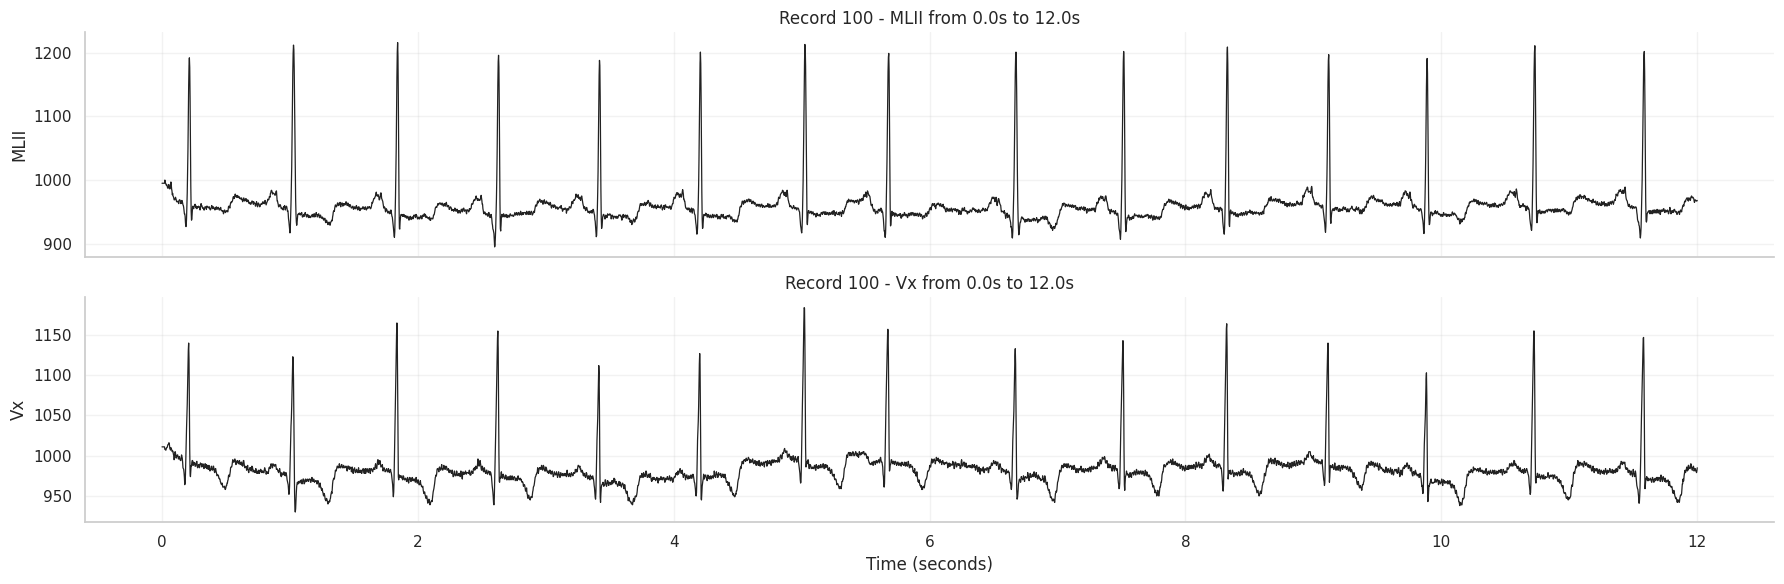

In [5]:
def plot_record_segment(record_id: str, start_second: float = 0.0, duration_second: float = 12.0) -> None:
    record = next(item for item in records if item['record_id'] == str(record_id))
    signals = record['signals']
    annotations = record['annotations']
    channel_columns = record['channel_columns']

    start_sample = int(start_second * SAMPLE_RATE)
    end_sample = int((start_second + duration_second) * SAMPLE_RATE)
    segment = signals[(signals['sample'] >= start_sample) & (signals['sample'] <= end_sample)].copy()
    if segment.empty:
        raise ValueError('Selected segment is empty')

    segment_time = (segment['sample'] - segment['sample'].iloc[0]) / SAMPLE_RATE + start_second

    fig, axes = plt.subplots(len(channel_columns), 1, figsize=(18, 6), sharex=True)
    if len(channel_columns) == 1:
        axes = [axes]

    palette = {'N': '#2ca25f', 'A': '#de2d26', 'V': '#3182bd', 'L': '#fd8d3c', 'R': '#756bb1', 'F': '#636363'}
    beat_rows = annotations[annotations['type'].map(is_beatsymbol)].copy() if not annotations.empty else pd.DataFrame()
    beat_rows = beat_rows[(beat_rows['sample'] >= start_sample) & (beat_rows['sample'] <= end_sample)] if not beat_rows.empty else beat_rows

    for axis, channel in zip(axes, channel_columns):
        axis.plot(segment_time, segment[channel], linewidth=0.9, color='#222222')
        axis.set_ylabel(channel)
        axis.set_title(f'Record {record_id} - {channel} from {start_second:.1f}s to {start_second + duration_second:.1f}s')
        if not beat_rows.empty:
            for _, row in beat_rows.iterrows():
                t = row['sample'] / SAMPLE_RATE
                label = row['type']
                axis.axvline(t, color=palette.get(label, '#e6550d'), alpha=0.35, linewidth=0.9)
        axis.grid(True, alpha=0.25)

    axes[-1].set_xlabel('Time (seconds)')
    plt.tight_layout()
    plt.show()

plot_record_segment('100', start_second=0, duration_second=12)

out_path = Path("/kaggle/working/label_pijes.png")
fig.savefig(out_path, dpi=150, bbox_inches='tight')

In [6]:
def rr_interval_summary() -> pd.DataFrame:
    rows = []
    for record in records:
        annotations = record['annotations']
        if annotations.empty:
            continue
        beat_rows = annotations[annotations['type'].map(is_beatsymbol)].sort_values('sample')
        if len(beat_rows) < 2:
            continue
        rr = np.diff(beat_rows['sample'].to_numpy()) / SAMPLE_RATE
        rows.append(pd.DataFrame({
            'record_id': record['record_id'],
            'rr_seconds': rr,
            'mean_rr': np.mean(rr),
            'median_rr': np.median(rr),
            'std_rr': np.std(rr, ddof=1) if len(rr) > 1 else np.nan,
        }))
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

rr_df = rr_interval_summary()
display(rr_df.head())

if not rr_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    sns.histplot(rr_df['rr_seconds'], bins=60, kde=True, ax=axes[0], color='#2b8cbe')
    axes[0].set_title('Phân bố RR interval toàn bộ dataset')
    axes[0].set_xlabel('RR (s)')

    rr_record_summary = rr_df.groupby('record_id')['rr_seconds'].agg(['mean', 'median', 'std', 'count']).reset_index()
    rr_record_summary = rr_record_summary.sort_values('mean', ascending=False)
    sns.boxplot(data=rr_df.sample(min(len(rr_df), 5000), random_state=42), x='record_id', y='rr_seconds', ax=axes[1], color='#a6bddb')
    axes[1].set_title('RR interval theo record (sample hoá để hiển thị)')
    axes[1].set_xlabel('Record')
    axes[1].set_ylabel('RR (s)')
    axes[1].tick_params(axis='x', rotation=90)
    plt.tight_layout()
    plt.show()

    display(rr_record_summary.head(10))

""


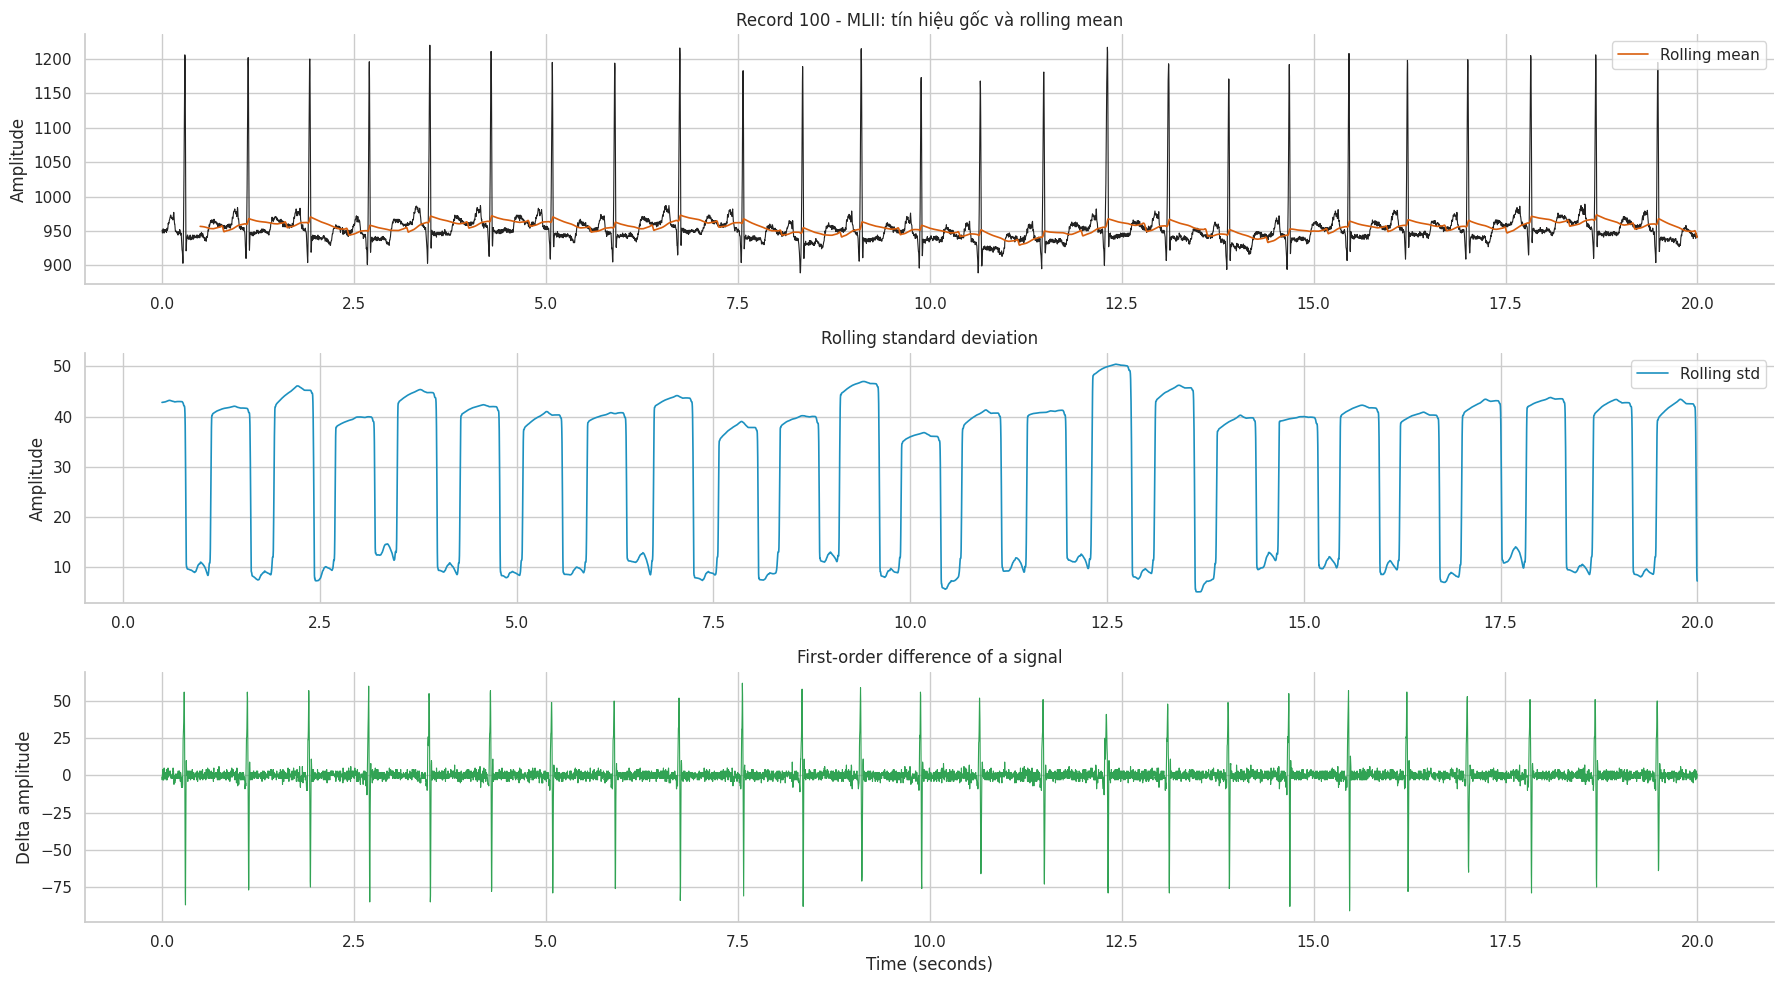

--- Original Signal ---
ADF stat: -12.6133 | p-value: 1.638e-23
ADF critical values: {'1%': np.float64(-3.43126312739421), '5%': np.float64(-2.8619435304007217), '10%': np.float64(-2.5669847951004168)}
KPSS stat: 0.4664 | p-value: 0.04923
KPSS critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


/tmp/ipykernel_57/3069359246.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(values, regression='c', nlags='auto')


--- First-Order Differenced Signal ---
ADF stat: -22.6377 | p-value: 0
ADF critical values: {'1%': np.float64(-3.4312632549182833), '5%': np.float64(-2.861943586747661), '10%': np.float64(-2.56698482509481)}
KPSS stat: 0.0047 | p-value: 0.1
KPSS critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


In [7]:
# Kiểm tra tính dừng trên một đoạn tín hiệu đại diện
selected_record_id = '100'
selected_channel = 'MLII' if 'MLII' in next(item for item in records if item['record_id'] == selected_record_id)['signals'].columns else next(item for item in records if item['record_id'] == selected_record_id)['channel_columns'][0]
selected_record = next(item for item in records if item['record_id'] == selected_record_id)
selected_signals = selected_record['signals']

window_seconds = 20
start_second = 2 * 60
start_sample = int(start_second * SAMPLE_RATE)
end_sample = int((start_second + window_seconds) * SAMPLE_RATE)
segment = selected_signals[(selected_signals['sample'] >= start_sample) & (selected_signals['sample'] < end_sample)].copy()
signal = segment[selected_channel].to_numpy(dtype=float)
signal_index_seconds = (segment['sample'].to_numpy() - segment['sample'].iloc[0]) / SAMPLE_RATE

rolling_window = max(5, SAMPLE_RATE // 2)
rolling_mean = pd.Series(signal).rolling(rolling_window).mean()
rolling_std = pd.Series(signal).rolling(rolling_window).std()
differenced_signal = np.diff(signal)

fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=False)
axes[0].plot(signal_index_seconds, signal, color='#222222', linewidth=0.8)
axes[0].plot(signal_index_seconds, rolling_mean, color='#d95f0e', linewidth=1.2, label='Rolling mean')
axes[0].set_title(f'Record {selected_record_id} - {selected_channel}: tín hiệu gốc và rolling mean')
axes[0].set_ylabel('Amplitude')
axes[0].legend(loc='upper right')

axes[1].plot(signal_index_seconds, rolling_std, color='#1d91c0', linewidth=1.2, label='Rolling std')
axes[1].set_title('Rolling standard deviation')
axes[1].set_ylabel('Amplitude')
axes[1].legend(loc='upper right')

axes[2].plot(signal_index_seconds[1:], differenced_signal, color='#31a354', linewidth=0.8)
axes[2].set_title('First-order difference of a signal')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylabel('Delta amplitude')

plt.tight_layout()
plt.show()

def print_stationarity_tests(values: np.ndarray, label: str) -> None:
    values = pd.Series(values).dropna().to_numpy(dtype=float)
    if len(values) < 20:
        print(f'{label}: không đủ dữ liệu cho test')
        return
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(values, autolag='AIC')
    try:
        kpss_stat, kpss_p, _, kpss_crit = kpss(values, regression='c', nlags='auto')
    except Exception as exc:
        kpss_stat, kpss_p, kpss_crit = np.nan, np.nan, {}
        print(f'KPSS failed for {label}: {exc}')
    print(f'--- {label} ---')
    print(f'ADF stat: {adf_stat:.4f} | p-value: {adf_p:.4g}')
    print(f'ADF critical values: {adf_crit}')
    if pd.notna(kpss_stat):
        print(f'KPSS stat: {kpss_stat:.4f} | p-value: {kpss_p:.4g}')
        print(f'KPSS critical values: {kpss_crit}')
print_stationarity_tests(signal, 'Original Signal')
print_stationarity_tests(differenced_signal, 'First-Order Differenced Signal')

out_path = Path("/kaggle/working/label_pijeẻts.png")
fig.savefig(out_path, dpi=150, bbox_inches='tight')

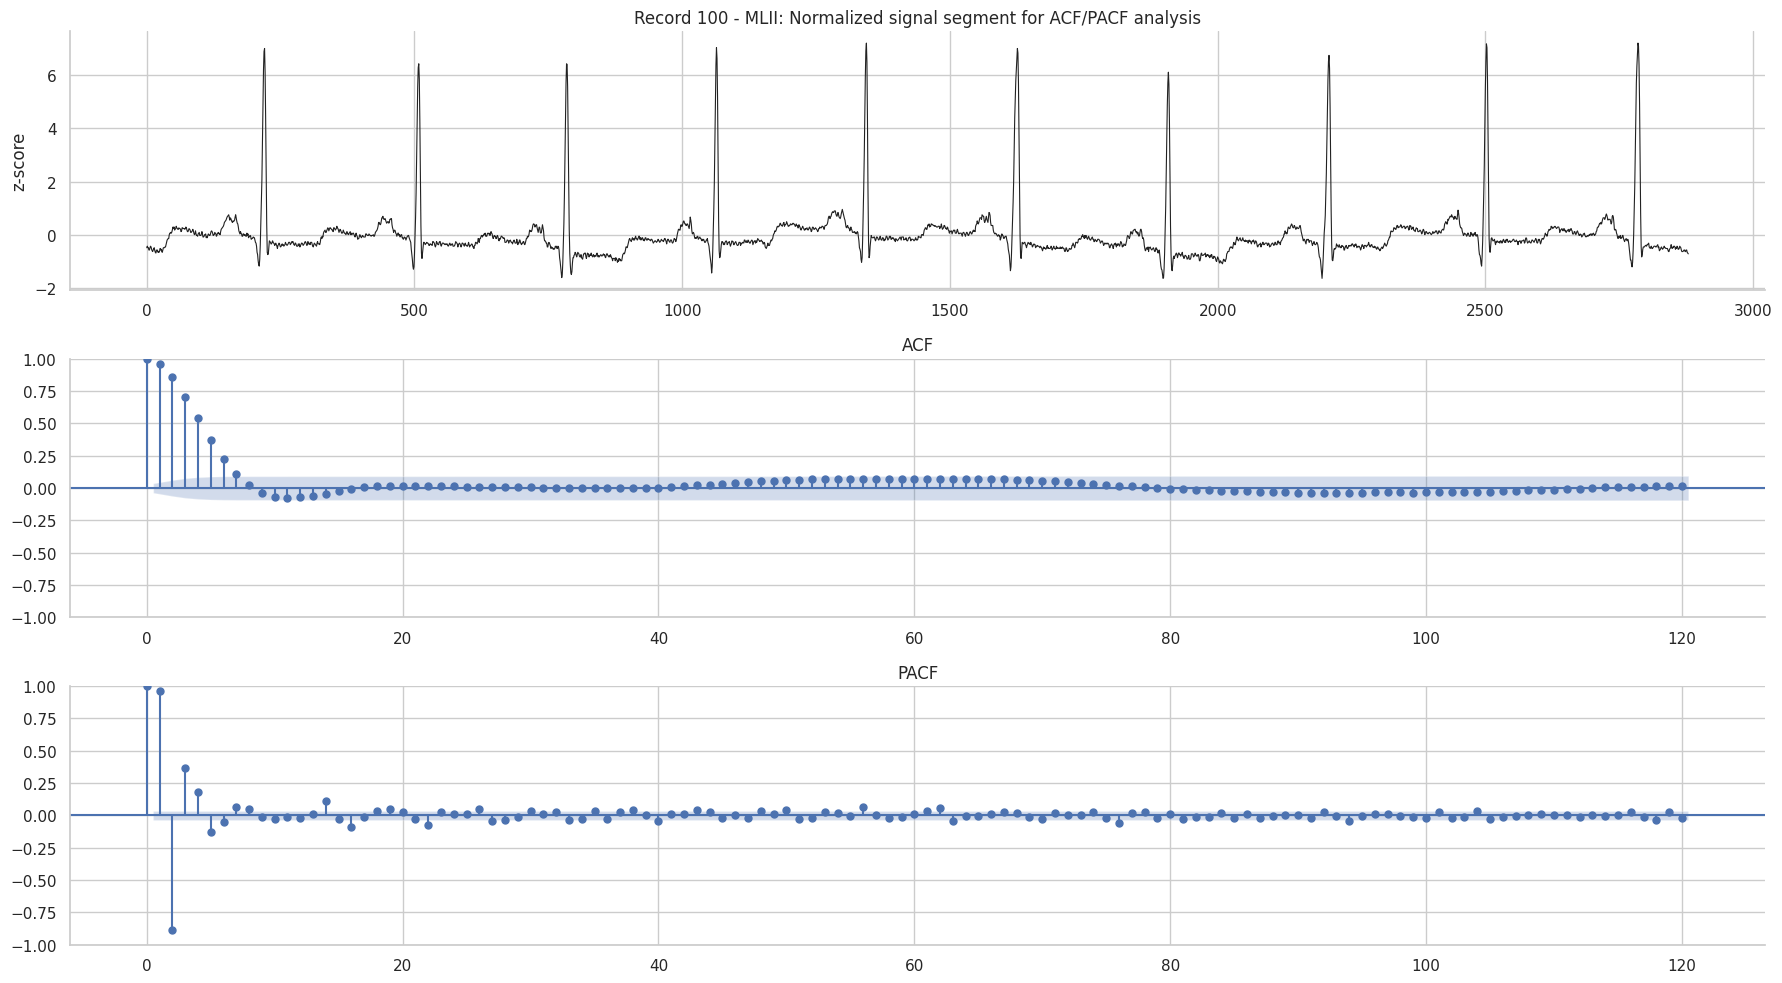

In [8]:
# ACF / PACF trên một cửa sổ tín hiệu ngắn
acf_window_seconds = 8
acf_start_second = 2 * 60 + 30
acf_start_sample = int(acf_start_second * SAMPLE_RATE)
acf_end_sample = int((acf_start_second + acf_window_seconds) * SAMPLE_RATE)
acf_segment = selected_signals[(selected_signals['sample'] >= acf_start_sample) & (selected_signals['sample'] < acf_end_sample)].copy()
acf_signal = acf_segment[selected_channel].to_numpy(dtype=float)
acf_signal = (acf_signal - np.nanmean(acf_signal)) / np.nanstd(acf_signal)

fig, axes = plt.subplots(3, 1, figsize=(18, 10))
axes[0].plot(acf_signal, color='#222222', linewidth=0.8)
axes[0].set_title(f'Record {selected_record_id} - {selected_channel}: Normalized signal segment for ACF/PACF analysis')
axes[0].set_ylabel('z-score')

plot_acf(acf_signal, lags=120, ax=axes[1])
axes[1].set_title('ACF')

plot_pacf(acf_signal, lags=120, ax=axes[2], method='ywm')
axes[2].set_title('PACF')

plt.tight_layout()
plt.show()

out_path = Path("/kaggle/working/label_pSDFijeẻts.png")
fig.savefig(out_path, dpi=150, bbox_inches='tight')

## Cách đọc kết quả

- Nếu rolling mean và rolling std thay đổi đáng kể theo thời gian, tín hiệu gốc chưa thể coi là stationary theo nghĩa chặt. Điều này là bình thường với ECG thô vì có baseline drift, nhịp tim biến thiên và các QRS spike.
- ADF thường cho thấy chuỗi đã sai phân có xu hướng gần stationary hơn chuỗi gốc. KPSS có thể nhạy với nhiễu và spike, nên nên đọc cùng với ADF thay vì chỉ nhìn một test.
- ACF/PACF của ECG thô thường cho thấy tự tương quan mạnh ở lags ngắn, phản ánh cấu trúc chu kỳ tim và tính lặp lại cục bộ của sóng ECG.
- Khi dùng cho mô hình hoá, nên cân nhắc chuẩn hoá theo record, lọc baseline, và nếu cần thì trích cửa sổ cố định theo beat hoặc theo nhịp RR.

## Gợi ý mở rộng

Nếu muốn đẩy notebook này lên mức phân tích nghiên cứu hơn nữa, có thể thêm:

- Spectrogram / Welch PSD cho từng kênh.
- So sánh các record có tỷ lệ beat bất thường cao nhất.
- Trích cửa sổ quanh R-peak để xem morphology theo từng lớp nhãn.
- PCA / UMAP trên feature thống kê của từng beat.
- Kiểm tra class imbalance để chuẩn bị cho bài toán classification.

Using data dir: /kaggle/input/datasets/mondejar/mitbih-database
✅ Found 48 annotation files
✅ Saved to: /kaggle/working/label_pies.png


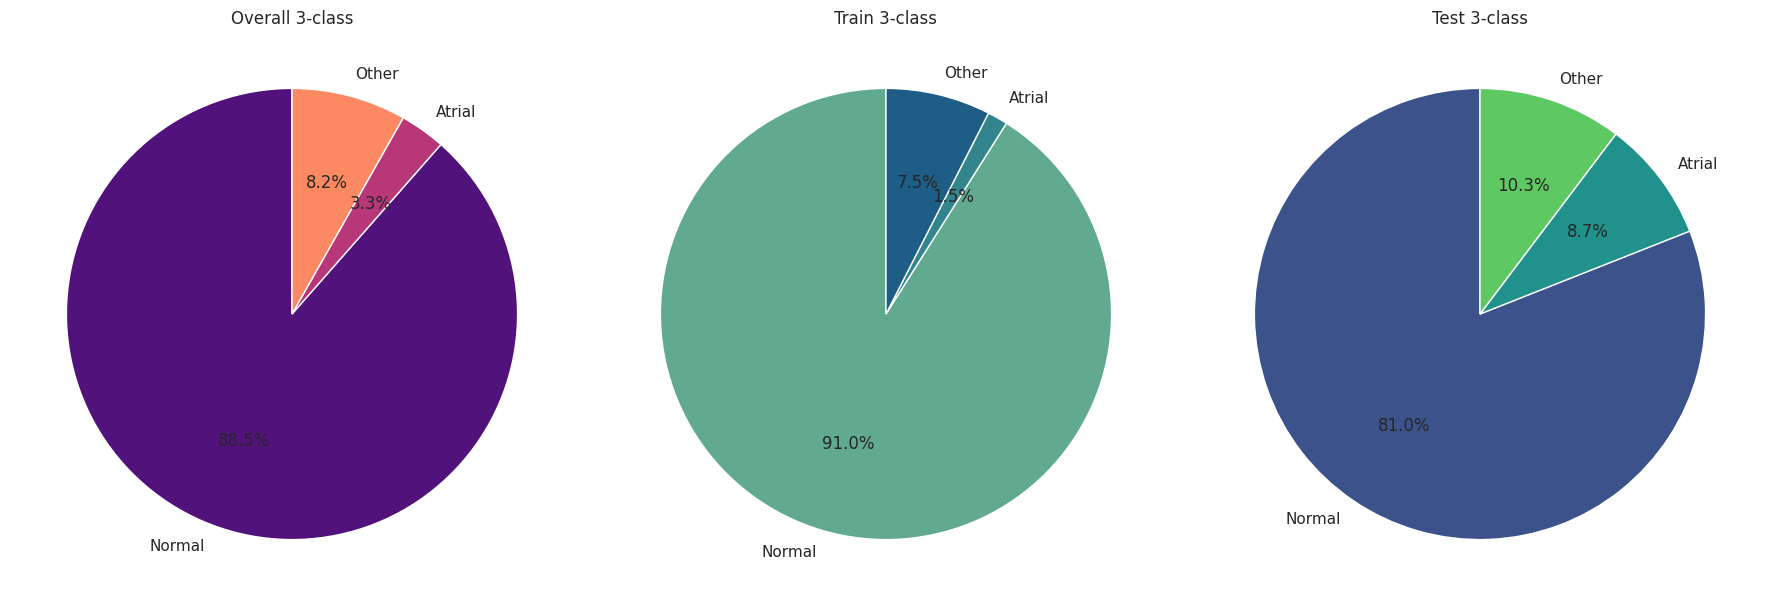

In [10]:
#!/usr/bin/env python3
from argparse import ArgumentParser
from collections import Counter
from pathlib import Path
import sys
import re

import matplotlib.pyplot as plt
import seaborn as sns

# ================= CONFIG =================
# 🔥 FIX: set path đúng cho Kaggle
DEFAULT_DATA_DIR = Path("/kaggle/input/datasets/mondejar/mitbih-database")

LABEL_MAP = {
    'N': 'Normal', 'L': 'Normal', 'R': 'Normal', 'e': 'Normal', 'j': 'Normal',
    'A': 'Atrial', 'a': 'Atrial', 'J': 'Atrial', 'S': 'Atrial',
    'V': 'Other', 'E': 'Other', 'F': 'Other',
    '/': 'Other', 'f': 'Other', 'Q': 'Other',
}

CLASSES_ORDER = ['Normal', 'Atrial', 'Other']

TRAIN_PATIENTS = {
    100, 101, 103, 105, 106, 108, 109, 111, 112, 115,
    116, 117, 118, 119, 121, 122, 123, 124, 200, 201,
    202, 203, 205, 207, 208, 209, 215,
}

TEST_PATIENTS = {220, 221, 222, 223, 228, 230, 231, 232, 233}

# ================= PARSE =================
def parse_annotation_file(path: Path):
    labels = []
    with path.open('r', encoding='utf-8', errors='ignore') as fh:
        for i, line in enumerate(fh, start=1):
            if i == 1 or not line.strip():
                continue
            parts = line.split()
            if len(parts) < 3:
                continue
            mapped_label = LABEL_MAP.get(parts[2])
            if mapped_label is None:
                continue
            labels.append(mapped_label)
    return labels


def record_id_from_path(path: Path) -> int | None:
    # 🔥 FIX: dùng regex cho chắc
    match = re.match(r'(\d+)', path.stem)
    if match:
        return int(match.group(1))
    return None


# ================= DATA DIR =================
def resolve_data_dir() -> Path:
    parser = ArgumentParser()
    parser.add_argument('--data-dir', type=Path, default=None)
    args, _ = parser.parse_known_args()

    if args.data_dir is not None:
        return args.data_dir.expanduser().resolve()

    # 🔥 fallback Kaggle
    return DEFAULT_DATA_DIR


# ================= MAIN =================
def main():
    data_dir = resolve_data_dir()
    print("Using data dir:", data_dir)

    # 🔥 FIX: đúng pattern
    ann_files = sorted(data_dir.glob('*annotations.txt'))

    if not ann_files:
        print("❌ Không tìm thấy annotation files")
        print("Files trong thư mục:")
        for f in data_dir.iterdir():
            print("-", f.name)
        sys.exit(1)

    print(f"✅ Found {len(ann_files)} annotation files")

    overall_labels = []
    train_labels = []
    test_labels = []

    for p in ann_files:
        rid = record_id_from_path(p)
        labels = parse_annotation_file(p)

        if not labels or rid is None:
            continue

        if rid in TRAIN_PATIENTS:
            train_labels.extend(labels)

        if rid in TEST_PATIENTS:
            test_labels.extend(labels)

        if rid in TRAIN_PATIENTS or rid in TEST_PATIENTS:
            overall_labels.extend(labels)

    if not overall_labels:
        print('❌ No labels parsed')
        sys.exit(1)

    overall_counter = Counter(overall_labels)
    train_counter = Counter(train_labels)
    test_counter = Counter(test_labels)

    def counts_for(counter: Counter):
        return [counter.get(label, 0) for label in CLASSES_ORDER]

    # ================= PLOT =================
    sns.set_theme(style='whitegrid')
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    pie_specs = [
        ('Overall 3-class', overall_counter, 'magma'),
        ('Train 3-class', train_counter, 'crest'),
        ('Test 3-class', test_counter, 'viridis'),
    ]

    for ax, (title, counter, palette_name) in zip(axes, pie_specs):
        sizes = counts_for(counter)
        total = sum(sizes)

        if total > 0:
            colors = sns.color_palette(palette_name, len(CLASSES_ORDER))
            ax.pie(
                sizes,
                labels=CLASSES_ORDER,
                autopct='%1.1f%%',
                startangle=90,
                colors=colors
            )
            ax.set_title(title)
        else:
            ax.text(0.5, 0.5, 'No labels', ha='center')
            ax.axis('off')

    plt.tight_layout()

    # 🔥 save để Kaggle download
    out_path = Path("/kaggle/working/label_pies.png")
    fig.savefig(out_path, dpi=150, bbox_inches='tight')

    print('✅ Saved to:', out_path)


# ================= RUN =================
if __name__ == '__main__':
    main()


out_path = Path("/kaggle/working/lab.png")
fig.savefig(out_path, dpi=150, bbox_inches='tight')